# Introducción al modelo a utilizar

Se presenta el modelo de redes neuronales entrenado mediante transfer learning, a partir del propuesto por Núñez et al. (2022), importándolo para mostrar su estructura, gráficos representativos de las series de tiempo que utiliza como entrada y la matriz de confusión para el set de pruebas. Adicionalmente, se presenta un gráfico de las predicciones de las dos clases posibles para todo el conjunto de prueba, destacando los casos en que el modelo se equivoca.


<u>Referencias:</u>
- Núñez, J., Catalán, P. A., Valle, C., Zamora, N., & Valderrama, A. (2022). Discriminating the occurrence of inundation in tsunami early warning with one-dimensional convolutional neural networks. Scientific Reports, 12(1). https://doi.org/10.1038/s41598-022-13788-9

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [2]:
import tensorflow as tf
import numpy as np
import random as rn

seed = 0 # Here sd means seed.
np.random.seed(seed)
rn.seed(seed)
os.environ['PYTHONHASHSEED']=str(seed)

from keras import backend as K
config = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1,inter_op_parallelism_threads=1)
tf.random.set_seed(seed)
#sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=config)
#K.set_session(sess)

C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

#from sklearn.preprocessing import MinMaxScaler
#from sklearn.metrics import mean_squared_error as MSE
#from sklearn.metrics import mean_absolute_error as MAE
#from sklearn.metrics import max_error

from keras.models import load_model

In [4]:
#Load data

def load_pickle(p_name):
    with open(p_name, 'rb') as file:
        # Load the data from the file
        data = pickle.load(file)
    return data

data_path = 'DATA\\'
ytest = load_pickle(data_path+'ytest_new.pickle')
xtest = load_pickle(data_path+'xtest_new.pickle')

In [13]:
# Load model

model_path = 'MODELS\\'
model = load_model(model_path+'transfer_learned_tsunami_classifier2.h5')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1_input (InputLayer)     │ (None, 241, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 78, 64)         │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 74, 32)         │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 72, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │       138,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 241)            │        29,161 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_dense_16 (Dense)            │ (None, 16)             │         3,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_dropout (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_output_sigmoid (Dense)      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,820 (729.77 KB)

 Trainable params: 3,889 (15.19 KB)

 Non-trainable params: 182,929 (714.57 KB)

 Optimizer params: 2 (12.00 B)

In [6]:
SMALL_SIZE = 29
MEDIUM_SIZE = 29
BIGGER_SIZE = 29

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


In [26]:
def plot_input_series(x, feature_names=None, title=None, 
                      fig_fmt='png', save_path=None):
    """
    Grafica las series de tiempo de entrada del modelo, una por boya.
    
    Args:
        x (ndarray):          Serie a graficar, shape (n_steps, n_features)
                              o (1, n_steps, n_features).
        feature_names (list): Nombres de las features/boyas. Default: None.
        title (str):          Título del gráfico. Default: None.
        fig_fmt (str):        Formato de figura: 'pdf' o 'png'. Default: 'png'.
        save_path (str):      Ruta base para guardar figura. Default: None.
    """


    # Asegurar shape correcto
    if x.ndim == 3:
        x = x[0]

    n_steps, n_features = x.shape
    timesteps = np.arange(n_steps)

    if feature_names is None:
        feature_names = [f'Boya {i+1}' for i in range(n_features)]

    # Paleta de colores distinguible
    colors = plt.cm.tab10(np.linspace(0, 1, n_features))

    fig, axes = plt.subplots(n_features, 1, figsize=(10, n_features * 2.5),
                             sharex=True)

    for i, ax in enumerate(axes):
        ax.plot(timesteps, x[:, i], color=colors[i], linewidth=1.5)
        ax.set_ylabel(feature_names[i], fontsize=12)
        ax.grid(alpha=0.3)

        # Sombrear área bajo la curva
        ax.fill_between(timesteps, x[:, i], alpha=0.1, color=colors[i])

        # Línea de referencia en cero
        ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
        ax.tick_params(axis='both', labelsize=10)
        
    axes[-1].set_xlabel('Timesteps', fontsize=12)

    if title:
        fig.suptitle(title, fontsize=13, y=1.01)
    else:
        fig.suptitle('Series de tiempo de entrada — Boyas', fontsize=13, y=1.01)

    plt.tight_layout()

    if save_path:
        fig.savefig(f'{save_path}_series_entrada.{fig_fmt}',
                    format=fig_fmt, dpi=300, bbox_inches='tight')
        print(f"Figura guardada: {save_path}_series_entrada.{fig_fmt}")

    plt.show()

Figura guardada: FIGS\_series_entrada.png


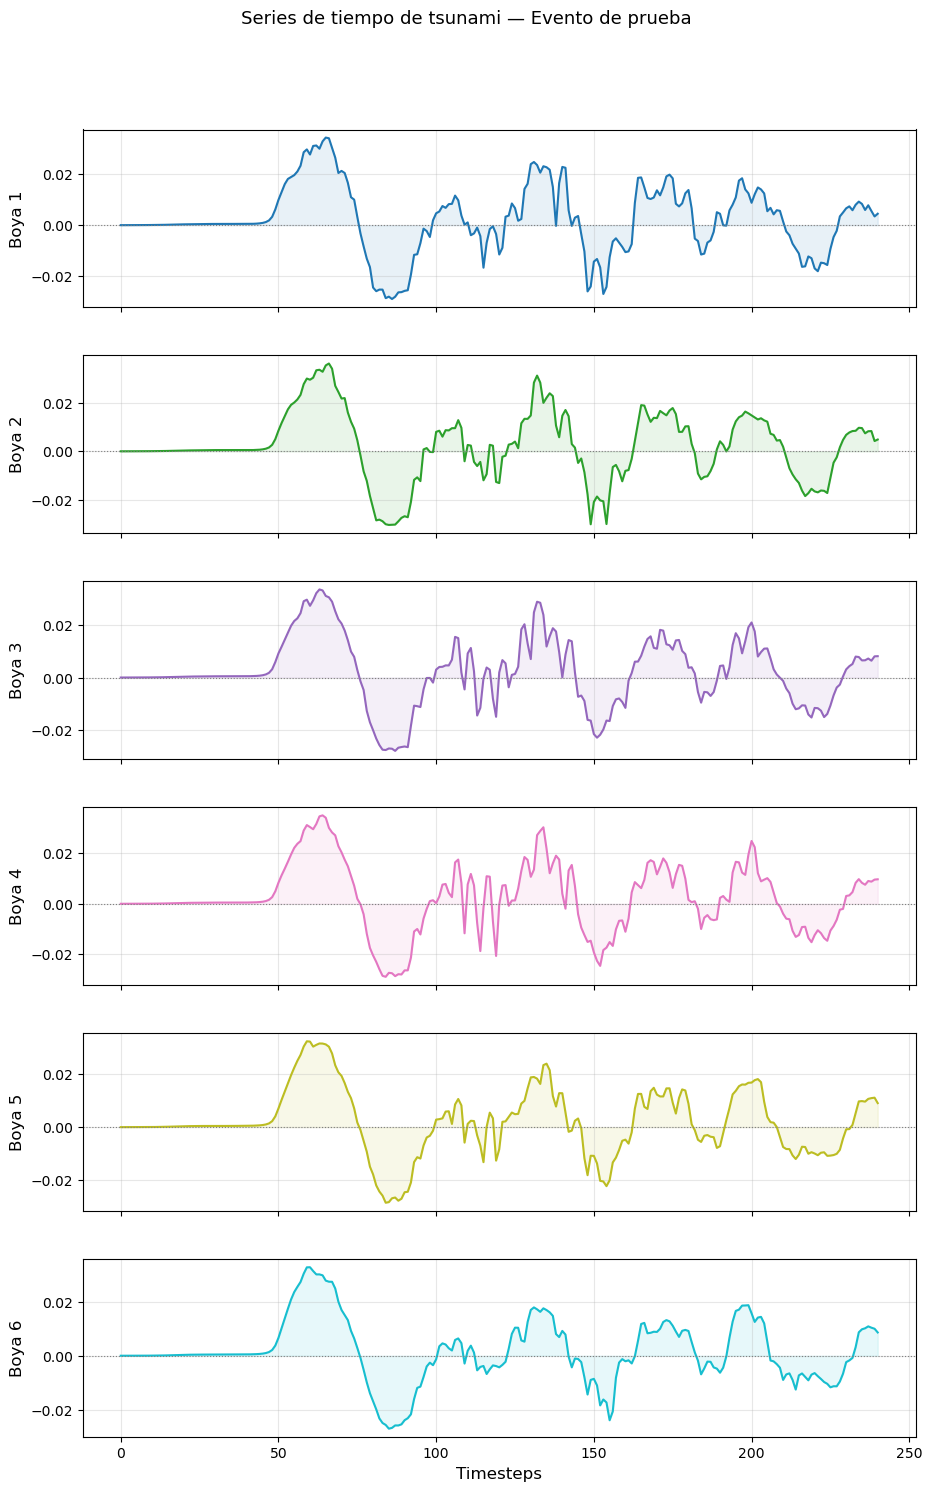

In [27]:
plot_input_series(
    x=xtest[0],
    feature_names=['Boya 1', 'Boya 2', 'Boya 3', 'Boya 4', 'Boya 5', 'Boya 6'],
    title='Series de tiempo de tsunami — Evento de prueba',
    fig_fmt='png',
    save_path='FIGS\\'
)

In [8]:
# PREDICCIONES DEL SET DE TEST

y_pred = model.predict(xtest)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


In [9]:
# Reorganización
y_pred = y_pred.reshape(len(y_pred),)
y_pred_binary = np.zeros((y_pred.shape))
y_pred_binary[y_pred>=0.5]=int(1)

In [10]:
# Compute confusion matrix
cm = tf.math.confusion_matrix(labels=ytest, predictions=y_pred_binary)
# Convert to numpy for plotting
cm_np = cm.numpy()

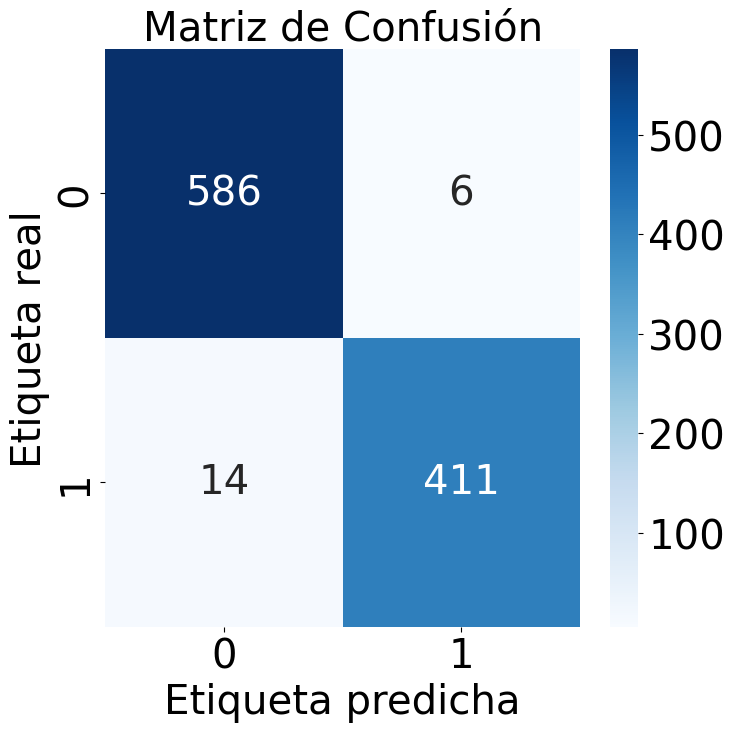

In [12]:
#Grafico de matriz de confusion

plt.figure(figsize=(8, 8))
sns.heatmap(cm_np, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Etiqueta predicha')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión')

# classes = ['No', 'Si'] # Your custom labels
# tick_marks = np.arange(len(classes))
# plt.xticks(tick_marks, classes, rotation=45) # Set X labels
# plt.yticks(tick_marks, classes)             # Set Y labels
plt.tight_layout()
plt.savefig('FIGS\\Matriz de confusion.png', format='png',dpi=300)
plt.show()

In [12]:
def F1_socre(y_pred, y_true):
    TP = len(np.where(y_pred==y_true)[0])
    FP = len(np.where(y_pred>y_true)[0])
    FN = len(np.where(y_pred<y_true)[0])
    F1 = 2*TP/(2*TP+FP+FN)
    return F1

    
TP = len(np.where(y_pred_binary==ytest)[0])
FP = len(np.where(y_pred_binary>ytest)[0])
FN = len(np.where(y_pred_binary<ytest)[0])

F1 = F1_socre(y_pred_binary,ytest)

print('Verdadero Positivo (TP): ',TP)
print('Falso Positivo (FP)    : ',FP)
print('Falso Negativo (FN)    : ',FN)
print('------------------------')
print('F1 Score               : ',f'{F1:.4f}')

Verdadero Positivo (TP):  997
Falso Positivo (FP)    :  6
Falso Negativo (FN)    :  14
------------------------
F1 Score               :  0.9901


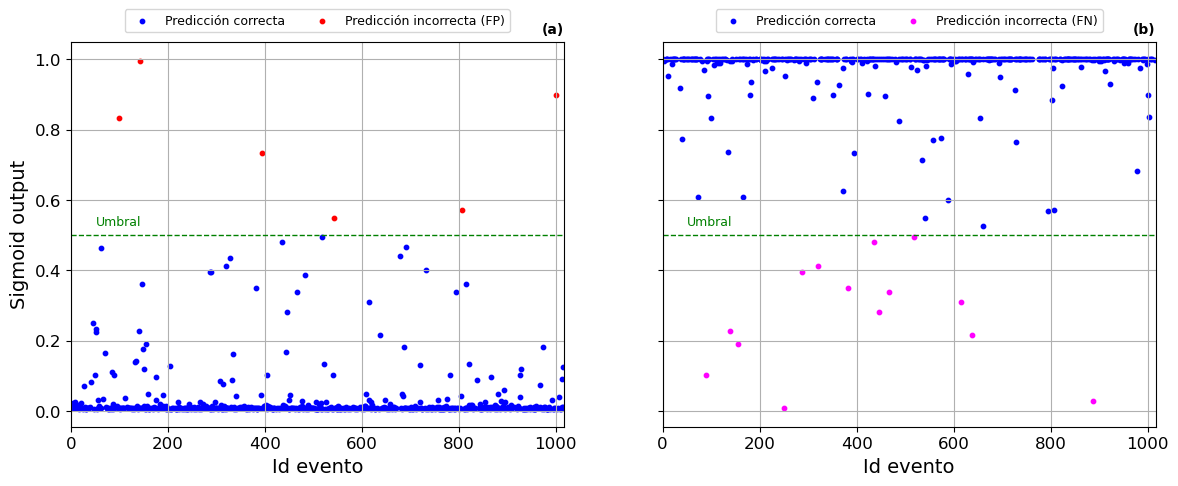

In [13]:
import string

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

FP_id = np.where(ytest-y_pred_binary<0) #Falsos Positivos
#axes[0].scatter(FP_id, ytest[FP_id], s=10, label='Clase correcta', color='blue')
noinu_id = np.where(y_pred<.5)
axes[0].scatter(noinu_id, y_pred[noinu_id], s=10, label='Predicción correcta', color='blue')
axes[0].scatter(FP_id, y_pred[FP_id], s=10, label='Predicción incorrecta (FP)', color='red')
axes[0].hlines(y=0.5, xmin=0, xmax=len(ytest), linewidth=1, color='g', linestyle='dashed')
axes[0].set_xlim([0,len(ytest)])
axes[0].legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', fontsize=9, ncol=2)
axes[0].text(0.05,0.55, 'Umbral', transform=axes[0].transAxes,color='g', fontsize=9,va='top',ha='left')

axes[0].grid()
axes[0].set_ylabel('Sigmoid output', fontsize=14)
axes[0].set_xlabel('Id evento', fontsize=14)
axes[0].xaxis.set_tick_params(labelsize=12); axes[0].yaxis.set_tick_params(labelsize=12)
axes[0].text(1, 1.05, '(a)', transform=axes[0].transAxes, fontweight='bold',
        fontsize=10, va='top', ha='right')


######################################################################333
FN_id = np.where(ytest-y_pred_binary>0) #Falsos negativos

#axes[1].scatter(FN_id, ytest[FN_id], s=10, label='Clase correcta', color='blue')
inu_id = np.where(y_pred>=.5)
axes[1].scatter(inu_id, y_pred[inu_id], s=10, label='Predicción correcta', color='blue')
axes[1].scatter(FN_id, y_pred[FN_id], s=10, label='Predicción incorrecta (FN)', color='magenta')
axes[1].hlines(y=0.5, xmin=0, xmax=len(ytest), linewidth=1, color='g', linestyle='dashed')
axes[1].set_xlim([0,len(ytest)])
axes[1].legend(bbox_to_anchor=(0.5, 1.2), loc='upper center', fontsize=12, ncol=2)
axes[1].text(0.05,0.55, 'Umbral', transform=axes[1].transAxes,color='g', fontsize=9,va='top',ha='left')


axes[1].legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', fontsize=9, ncol=2)
axes[1].grid()
axes[1].set_xlabel('Id evento', fontsize=14)
axes[1].xaxis.set_tick_params(labelsize=12); axes[1].yaxis.set_tick_params(labelsize=12)
axes[1].text(1, 1.05, '(b)', transform=axes[1].transAxes, fontweight='bold',
        fontsize=10, va='top', ha='right')

plt.savefig('FIGS\\falsos_positivos y negativos.png',format='png',dpi=300)
plt.show()